In [1]:
# Site configuration — uses transformation/flood_hazard city configs
import os
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
_FLOOD_HAZARD = None
for _candidate in [_HERE, *_HERE.parents]:
    _probe = _candidate / "flood_hazard" if _candidate.name != "flood_hazard" else _candidate
    if (_probe / "site_config.py").is_file() and (_probe / "config" / "sites").is_dir():
        _FLOOD_HAZARD = _probe
        break
if _FLOOD_HAZARD is None:
    raise FileNotFoundError("Could not locate transformation/flood_hazard from notebook cwd")

sys.path.insert(0, str(_FLOOD_HAZARD))
from site_config import configured_path, load_site_config

FLOOD_HAZARD_ROOT = _FLOOD_HAZARD
FLOODS_ROOT = FLOOD_HAZARD_ROOT  # backward-compatible alias

# Set the city here (edit this). Optional: export FLOODS_SITE=... to override.
SITE_SLUG = "plymouth"  # porto_alegre | plymouth | edina | richfield | rochester | apple_valley
if "FLOODS_SITE" in os.environ:
    SITE_SLUG = os.environ["FLOODS_SITE"]
SITE_CONFIG = load_site_config(SITE_SLUG, FLOOD_HAZARD_ROOT)
SITE_ROOT = SITE_CONFIG["paths_abs"]["site_root"]
INPUT_DIR = SITE_CONFIG["paths_abs"]["data_input"]
INTERMEDIATE_DIR = SITE_CONFIG["paths_abs"]["data_intermediate"]
OUTPUT_DIR = SITE_CONFIG["paths_abs"]["data_output"]
OUT_ROOT = SITE_CONFIG["paths_abs"]["out"]
CACHE_DIR = SITE_CONFIG["paths_abs"]["cache"]
STYLES_DIR = SITE_CONFIG["paths_abs"]["styles"]
OUTPUT_PREFIX = SITE_CONFIG["output_prefix"]
print(f"Flood hazard site: {SITE_CONFIG['display_name']} ({SITE_SLUG})")
print(f"Config: {SITE_CONFIG['config_path']}")
print(f"Inputs -> {INPUT_DIR}")


Flood hazard site: Plymouth (plymouth)
Config: /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/config/sites/plymouth.yaml
Inputs -> /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input


In [2]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import geemap
import ee, datetime

In [3]:
# Access Earth Engine
ee.Authenticate()
ee.Initialize(
    project = 'eecc-maureen',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)


In [4]:
# Site ROI: use the site polygon when available; fall back to bbox.
import json


def load_site_roi() -> ee.Geometry:
    boundary_path = SITE_CONFIG["boundary_path_abs"]
    if boundary_path.exists():
        data = json.loads(boundary_path.read_text())
        if data.get("type") == "FeatureCollection":
            features = [
                ee.Feature(ee.Geometry(feature["geometry"]), feature.get("properties", {}))
                for feature in data.get("features", [])
                if feature.get("geometry")
            ]
            if features:
                return ee.FeatureCollection(features).geometry()
        if data.get("type") == "Feature":
            return ee.Geometry(data["geometry"])
        if data.get("type") in {"Polygon", "MultiPolygon", "GeometryCollection"}:
            return ee.Geometry(data)

    return ee.Geometry.Rectangle(SITE_CONFIG["bbox"])


roi = load_site_roi()
site_geom = roi
poa = roi  # Backward-compatible alias used by existing cells.
print(f"ROI loaded for {SITE_CONFIG['display_name']} from {SITE_CONFIG['boundary_path_abs']}")


ROI loaded for Plymouth from /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/boundary/site.geojson


# WRI Aqueduct Floods Hazard Maps Version 2

**Preferred batch path:**

```bash
python transformation/wri_aqueduct/extract_aqueduct.py --site plymouth
```

This notebook remains useful for interactive maps / histograms. Exports land under `flood_hazard/sites/<city>/data/input/`.

Dataset Availability:
- 2010-01-01–2018-12-31 (historical scenario in notebook filters)
Dataset Availability:
- 2010-01-01–2080-12-31

Pixel size: 
- 1000 meters (all bands)

Terms of Use
- The WRI datasets are available without restriction on use or distribution. WRI does request that the user give proper attribution and identify WRI, where applicable, as the source of the data.


In [5]:
dataset = (ee.ImageCollection("WRI/Aqueduct_Flood_Hazard_Maps/V2"))

In [6]:
# Optional checks
print("Total images:", dataset.size().getInfo())
print("Flood types:", ee.List(dataset.aggregate_array("floodtype")).distinct().getInfo())
print("Climate scenarios:", ee.List(dataset.aggregate_array("climatescenario")).distinct().getInfo())
print("Years:", ee.List(dataset.aggregate_array("year")).distinct().getInfo())
print("Return periods:", ee.List(dataset.aggregate_array("returnperiod")).distinct().getInfo())
print("Models:", ee.List(dataset.aggregate_array("model")).distinct().getInfo())
print("First image:", dataset.first().getInfo())


Total images: 648
Flood types: ['inuncoast', 'inunriver']
Climate scenarios: ['historical', 'rcp4p5', 'rcp8p5']
Years: [2010, 2030, 2050, 2080, 1980]
Return periods: [2, 5, 10, 25, 50, 100, 250, 500, 1000]
Models: ['000000000WATCH', '00000NorESM1-M', '0000GFDL-ESM2M', '0000HadGEM2-ES', '00IPSL-CM5A-LR', 'MIROC-ESM-CHEM']
First image: {'type': 'Image', 'bands': [{'id': 'inundation_depth', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [43200, 21600], 'crs': 'EPSG:4326', 'crs_transform': [0.008333333333333333, 0, -180, 0, -0.008333333333333333, 90]}], 'version': 1712176160146141, 'id': 'WRI/Aqueduct_Flood_Hazard_Maps/V2/inuncoast_historical_nosub_hist_rp0002_0', 'properties': {'floodtype': 'inuncoast', 'year': 2010, 'system:time_end': 1293840000000, 'returnperiod': 2, 'system:time_start': 1262304000000, 'climatescenario': 'historical', 'system:footprint': {'type': 'LinearRing', 'coordinates': [[-180, -90], [180, -90], [180, 90], [-180, 90], [-180, -90]]}, 'subsid

In [7]:
river_historical = (
    dataset
    .filter(ee.Filter.eq("floodtype", "inunriver"))
    .filter(ee.Filter.eq("returnperiod", 100))
    .filter(ee.Filter.eq("climatescenario", "historical"))
)

print("River historical size:", river_historical.size().getInfo())
print("River historical sample:", river_historical.limit(10).getInfo())

river_historical_100yr = ee.Image(river_historical.first())


River historical size: 1
River historical sample: {'type': 'ImageCollection', 'bands': [], 'version': 1729607528381344, 'id': 'WRI/Aqueduct_Flood_Hazard_Maps/V2', 'features': [{'type': 'Image', 'bands': [{'id': 'inundation_depth', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [43200, 21600], 'crs': 'EPSG:4326', 'crs_transform': [0.008333333333333333, 0, -180, 0, -0.008333333333333333, 90]}], 'version': 1712176059696603, 'id': 'WRI/Aqueduct_Flood_Hazard_Maps/V2/inunriver_historical_000000000WATCH_1980_rp00100', 'properties': {'floodtype': 'inunriver', 'system:time_start': 315532800000, 'climatescenario': 'historical', 'year': 1980, 'system:footprint': {'type': 'LinearRing', 'coordinates': [[-180, -90], [180, -90], [180, 90], [-180, 90], [-180, -90]]}, 'system:time_end': 347068800000, 'returnperiod': 100, 'model': '000000000WATCH', 'system:asset_size': 48257558, 'system:index': 'inunriver_historical_000000000WATCH_1980_rp00100'}}]}


Raw depth stats: {'inundation_depth_count': 150, 'inundation_depth_max': 0, 'inundation_depth_min': 0, 'inundation_depth_p10': 0, 'inundation_depth_p25': 0, 'inundation_depth_p50': 0, 'inundation_depth_p75': 0, 'inundation_depth_p90': 0, 'inundation_depth_p95': 0, 'inundation_depth_p99': 0}
n=129
<=0.15m 100.0% | <=0.5m 100.0% | <=1m 100.0% | >2m 0.0%


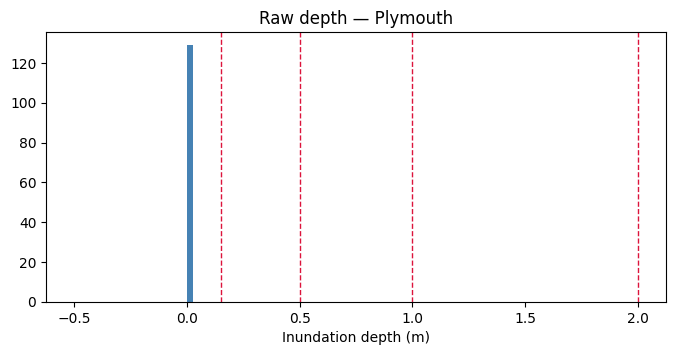

In [11]:
# Raw depth histogram (before normalization)
import numpy as np
import matplotlib.pyplot as plt

stats = depth.reduceRegion(
    reducer=(
        ee.Reducer.minMax()
        .combine(ee.Reducer.percentile([10, 25, 50, 75, 90, 95, 99]), sharedInputs=True)
        .combine(ee.Reducer.count(), sharedInputs=True)
    ),
    geometry=roi,   # no uses poa
    scale=1000,     # Aqueduct; en JRC usa 90 y depth100
    maxPixels=1e9,
    bestEffort=True,
).getInfo()
print("Raw depth stats:", stats)

sample = depth.sample(region=roi, scale=1000, numPixels=4000, seed=42, geometries=False)
vals = np.array(sample.aggregate_array(depth.bandNames().get(0)).getInfo(), dtype=float)
vals = vals[np.isfinite(vals)]
print(f"n={vals.size}")
if vals.size:
    print(
        f"<=0.15m {(vals<=0.15).mean()*100:.1f}% | "
        f"<=0.5m {(vals<=0.5).mean()*100:.1f}% | "
        f"<=1m {(vals<=1).mean()*100:.1f}% | "
        f">2m {(vals>2).mean()*100:.1f}%"
    )
    plt.figure(figsize=(8, 3.5))
    plt.hist(vals, bins=40, color="steelblue")
    for x in (0.15, 0.5, 1.0, 2.0):
        plt.axvline(x, color="crimson", ls="--", lw=1)
    plt.xlabel("Inundation depth (m)")
    plt.title(f"Raw depth — {SITE_CONFIG['display_name']}")
    plt.show()

## Flood hazard scoring by inundation depth (CCRA)

### Why this approach
- For climate risk screening, **interpretability** is a priority: stakeholders can directly understand classes in meters of water depth.
- A class-based mapping is easier to communicate than continuous normalization and is better aligned with decision workflows (screening/prioritization).
- This avoids dependence on AOI-specific min/max values and keeps a stable interpretation across runs.

### What this score is for
- Build a **hazard-only** base layer from Aqueduct inundation depth for the MVP.
- Support hotspot screening and relative prioritization in early-stage assessments.
- Provide a transparent intermediate layer that can later be combined with exposure/vulnerability.

### Classification rule (depth -> hazard score)
- 0-0.15 m -> 0
- 0.15-0.5 m -> 0.25
- 0.5-1.0 m -> 0.5
- 1.0-2.0 m -> 0.75
- \>2.0 m -> 1.0


In [8]:
# Select inundation depth and classify to an interpretable hazard score.
image = river_historical_100yr.clip(poa)
depth = image.select("inundation_depth")

flood_hazard_score = depth.expression(
    "(d <= 0.15) ? 0"
    ": (d <= 0.5) ? 0.25"
    ": (d <= 1.0) ? 0.5"
    ": (d <= 2.0) ? 0.75"
    ": 1",
    {"d": depth},
).rename("flood_hazard_score")

# Preserve nodata from depth: no score where depth has no value.
flood_hazard_score = flood_hazard_score.updateMask(depth.mask()).clip(poa)

print("✅ flood_hazard_score created from inundation_depth classes (nodata preserved)")


✅ flood_hazard_score created from inundation_depth classes (nodata preserved)


In [9]:
# Visual check: depth vs classified hazard score
m = geemap.Map()
m.centerObject(poa, 11)

# Depth visualization (meters)
depth_vis = {
    "min": 0,
    "max": 3,
    "palette": ["f7fbff", "c6dbef", "6baed6", "2171b5", "08306b"],
}

# Classified hazard score visualization (0, 0.25, 0.5, 0.75, 1)
hazard_vis = {
    "min": 0,
    "max": 1,
    "palette": ["f7f7f7", "c7e9c0", "74c476", "238b45", "00441b"],
}

m.addLayer(depth, depth_vis, "Aqueduct inundation depth (m)")
m.addLayer(flood_hazard_score, hazard_vis, "Flood hazard score (classified)")
m.addLayer(ee.Image().paint(poa, 1, 2), {"palette": ["red"]}, "POA boundary")

# Discrete legend to avoid interpretation ambiguity.
legend_labels = [
    "0.00 -> 0-0.15 m",
    "0.25 -> 0.15-0.5 m",
    "0.50 -> 0.5-1.0 m",
    "0.75 -> 1.0-2.0 m",
    "1.00 -> >2.0 m",
]
legend_colors = ["#f7f7f7", "#c7e9c0", "#74c476", "#238b45", "#00441b"]
m.add_legend(
    title="Flood hazard score classes",
    keys=legend_labels,
    colors=legend_colors,
    position="bottomright",
)

m

Map(center=[45.02238616047533, -93.4615216182928], controls=(WidgetControl(options=['position', 'transparent_b…

In [12]:
# Numeric check: pixel distribution by hazard class inside POA
class_hist = flood_hazard_score.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=poa,
    scale=1000,
    maxPixels=1e9,
)

hist_dict = ee.Dictionary(class_hist.get("flood_hazard_score")).getInfo()
print("Hazard class pixel counts (approx. at 1km scale):")
print(hist_dict)

# Ordered view for quick interpretation
class_order = [0, 0.25, 0.5, 0.75, 1]
ordered_counts = {c: hist_dict.get(str(c), 0) for c in class_order}
print("Ordered counts:", ordered_counts)


Hazard class pixel counts (approx. at 1km scale):
{'0.0': 129.78431372549016}
Ordered counts: {0: 0, 0.25: 0, 0.5: 0, 0.75: 0, 1: 0}


In [13]:
# --- Export Aqueduct depth + norm to site input/ (local by default) ---
# Override: export GEE_EXPORT_MODE=drive

from gee_local_export import export_image_to_input

scale_m = 1000
crs = "EPSG:4326"
drive_folder = "OEF_Aqueduct_Depth"

export_image_to_input(
    depth,
    filename=SITE_CONFIG["layers"]["aqueduct_depth"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"aqueduct_depth_rp100_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)
export_image_to_input(
    flood_hazard_score,
    filename=SITE_CONFIG["layers"]["aqueduct_norm"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"aqueduct_depth_rp100_norm_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)

print("Exports complete. Files land under:", INPUT_DIR)


[local] exporting aqueduct_depth_rp100_plymouth.tif → /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/aqueduct_depth_rp100_plymouth.tif (scale=1000m, crs=EPSG:4326)
Generating URL ...
Please wait ...
Data downloaded to /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/aqueduct_depth_rp100_plymouth.tif
[local] wrote /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/aqueduct_depth_rp100_plymouth.tif (0.00 MB)
[local] exporting aqueduct_depth_rp100_norm_plymouth.tif → /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/aqueduct_depth_rp100_norm_plymouth.tif (scale=1000m, crs=EPSG:4326)
Generating URL ...
Please wait ...
Data downloaded to /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/aqueduct_depth_rp100_norm_plymouth.tif
[local] wrote /Users/admin/Desktop/OEF/geo

#### Convert Aqueduct RP100 Depth to COG and Generate Tiles

Publish the local `sites/<site_slug>/data/input/aqueduct_depth_rp100_poa.tif` raster for web maps: COG + colorized XYZ tiles + value-encoded XYZ tiles for hover lookup.

Requires GDAL CLI (`gdal_translate`, `gdaldem`, `gdal_calc.py`, `gdal2tiles.py`) and `data/aqueduct_depth_rp100_colors.txt`.


In [ ]:
# Convert Aqueduct RP100 depth GeoTIFF to COG + visual tiles + value tiles
# Input expected after downloading the Earth Engine export from Google Drive.
from pathlib import Path
import shutil
import subprocess


PROJECT_ROOT = FLOODS_ROOT
in_tif = INPUT_DIR / SITE_CONFIG["layers"]["aqueduct_depth"]
out_dir = OUT_ROOT / "aqueduct_depth_rp100"
colors_txt = STYLES_DIR / "aqueduct_depth_rp100_colors.txt"

slug = "aqueduct_depth_rp100"
cog_tif = out_dir / f"{slug}_cog.tif"
colorized_tif = out_dir / f"{slug}_colorized.tif"
value_encoded_tif = out_dir / f"{slug}_value_encoded_rgb.tif"
tiles_dir = out_dir / "tiles_visual"
value_tiles_dir = out_dir / "tiles_values"
decode_txt = out_dir / f"{slug}_value_tiles_decode.txt"

out_dir.mkdir(parents=True, exist_ok=True)
if not in_tif.exists():
    raise FileNotFoundError(f"Missing input raster: {in_tif}")
if not colors_txt.exists():
    raise FileNotFoundError(f"Missing color table: {colors_txt}")

print("Input:", in_tif)
print("Output dir:", out_dir)

# 1) COG preserving raw depth in meters.
subprocess.run([
    "gdal_translate", str(in_tif), str(cog_tif),
    "-of", "COG",
    "-ot", "Float32",
    "-co", "COMPRESS=DEFLATE",
    "-co", "RESAMPLING=NEAREST",
    "-co", "OVERVIEWS=AUTO",
], check=True)
print("Created COG:", cog_tif)

# 2) Colorized raster + visual XYZ tiles.
subprocess.run([
    "gdaldem", "color-relief",
    str(cog_tif), str(colors_txt), str(colorized_tif),
    "-alpha",
], check=True)
print("Created colorized raster:", colorized_tif)

# gdal2tiles preflight: use the Python interpreter referenced by gdal2tiles.py.
gdal2tiles = shutil.which("gdal2tiles.py")
if not gdal2tiles:
    raise RuntimeError("gdal2tiles.py not found in PATH. Install GDAL (e.g. brew install gdal).")

gdal2tiles_python = None
with open(gdal2tiles, "r", encoding="utf-8", errors="ignore") as f:
    first_line = f.readline().strip()
if first_line.startswith("#!"):
    shebang_parts = first_line[2:].split()
    if shebang_parts:
        if shebang_parts[0].endswith("env") and len(shebang_parts) > 1:
            gdal2tiles_python = shutil.which(shebang_parts[1])
        else:
            gdal2tiles_python = shebang_parts[0]
if not gdal2tiles_python:
    gdal2tiles_python = shutil.which("python3") or shutil.which("python")
subprocess.run([gdal2tiles_python, "-c", "import numpy"], check=True, capture_output=True)

tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(colorized_tif),
    str(tiles_dir),
], check=True)
print("Visual tiles:", tiles_dir)

# 3) Value tiles for client-side hover.
# Encodes depth in millimeters plus 1 so encoded RGB value 0 can mean nodata.
# Decode: encoded = R + 256*G + 65536*B; depth_m = (encoded - 1) / 1000; encoded == 0 => nodata.
base_expr = (
    "numpy.where(numpy.isnan(A), 0, "
    "numpy.rint(numpy.clip(A,0,10000)*1000).astype(numpy.int64) + 1)"
)
subprocess.run([
    "gdal_calc.py",
    "-A", str(cog_tif),
    "--calc", f"bitwise_and({base_expr},255)",
    "--calc", f"bitwise_and(right_shift({base_expr},8),255)",
    "--calc", f"bitwise_and(right_shift({base_expr},16),255)",
    "--type", "Byte",
    "--NoDataValue", "0",
    "--overwrite",
    "--outfile", str(value_encoded_tif),
], check=True)

value_tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(value_encoded_tif),
    str(value_tiles_dir),
], check=True)

metadata = """Aqueduct RP100 depth value tiles

Source raster: sites/<site_slug>/data/input/aqueduct_depth_rp100_poa.tif
COG: sites/<site_slug>/out/aqueduct_depth_rp100/aqueduct_depth_rp100_cog.tif
Visual tiles: sites/<site_slug>/out/aqueduct_depth_rp100/tiles_visual/{z}/{x}/{y}.png
Value tiles: sites/<site_slug>/out/aqueduct_depth_rp100/tiles_values/{z}/{x}/{y}.png

Value tile encoding:
encoded = R + 256 * G + 65536 * B
if encoded == 0: value is nodata
else: depth_m = (encoded - 1) / 1000

Depth values are stored in meters and encoded at millimeter precision.
"""
decode_txt.write_text(metadata, encoding="utf-8")

print("Value tiles:", value_tiles_dir)
print("Decode metadata:", decode_txt)
print("Decode: encoded = R + 256*G + 65536*B; depth_m = (encoded - 1) / 1000; encoded 0 = nodata")


## Optional approach to: Avoid assigning hazard scores to permanent water bodies (not applied)


In [ ]:
# Avoid assigning hazard scores to permanent water bodies (e.g., Lago Guaiba).
# 1) Keep score only where depth has valid data.
flood_hazard_score_valid = flood_hazard_score.updateMask(depth.mask())

# 2) Build a permanent-water mask from JRC Global Surface Water.
# occurrence: percentage of time water was present (1984-2021).
# >=90 is a conservative threshold for permanent water.
gsw_occurrence = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence")
permanent_water = gsw_occurrence.gte(90)
land_mask = permanent_water.Not()

# 3) Apply land-only mask to depth and hazard score.
depth_land = depth.updateMask(land_mask).rename("inundation_depth_land")
flood_hazard_score_land = (
    flood_hazard_score_valid
    .updateMask(land_mask)
    .rename("flood_hazard_score_land")
)

print("✅ Land-only layers created: depth_land, flood_hazard_score_land")


In [ ]:
# Visual check after water masking
m_land = geemap.Map()
m_land.centerObject(poa, 11)

depth_land_vis = {
    "min": 0,
    "max": 3,
    "palette": ["f7fbff", "c6dbef", "6baed6", "2171b5", "08306b"],
}

hazard_land_vis = {
    "min": 0,
    "max": 1,
    "palette": ["f7f7f7", "c7e9c0", "74c476", "238b45", "00441b"],
}

m_land.addLayer(depth_land.clip(poa), depth_land_vis, "Depth land-only")
m_land.addLayer(flood_hazard_score_land.clip(poa), hazard_land_vis, "Hazard score land-only")
m_land.addLayer(ee.Image().paint(poa, 1, 2), {"palette": ["red"]}, "POA boundary")

m_land


### Methodological notes for documentation draft - future applicability

In future iterations, this product can be expanded to support scenario-based and frequency-based analysis using the dimensions available in Aqueduct:

- Flood types: `['inuncoast', 'inunriver']`
- Climate scenarios: `['historical', 'rcp4p5', 'rcp8p5']`
- Years: `[2010, 2030, 2050, 2080, 1980]`
- Return periods: `[2, 5, 10, 25, 50, 100, 250, 500, 1000]`

This enables producing comparable hazard outputs across flood mechanism, climate pathway, reference year, and event rarity.


# Comparison between different return periods


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Compare depth maps across return periods using a shared color scale.
return_periods = [2, 5, 10, 25, 50, 100, 250, 500, 1000]

river_historical_all_rp = (
    dataset
    .filter(ee.Filter.eq("floodtype", "inunriver"))
    .filter(ee.Filter.eq("climatescenario", "historical"))
)

# Build one depth image per return period (if available).
depth_images = []
valid_rps = []
for rp in return_periods:
    ic_rp = river_historical_all_rp.filter(ee.Filter.eq("returnperiod", rp))
    if ic_rp.size().getInfo() > 0:
        img_rp = ee.Image(ic_rp.first()).select("inundation_depth").clip(poa)
        depth_images.append(img_rp)
        valid_rps.append(rp)

if len(depth_images) == 0:
    raise ValueError("No images found for selected return periods.")

# Shared visualization scale across all panels (same vmin/vmax for comparability).
global_max_dict = (
    ee.ImageCollection(depth_images)
    .max()
    .reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=poa,
        scale=1000,
        maxPixels=1e9,
    )
    .getInfo()
)

global_max = global_max_dict.get("inundation_depth", 3.0)
if global_max is None or global_max <= 0:
    global_max = 3.0

global_min = 0.0

# Convert each EE image to numpy for plotting.
arrays = []
for img in depth_images:
    arr = geemap.ee_to_numpy(img, region=poa, scale=1000)
    arr2d = arr[:, :, 0] if arr.ndim == 3 else arr
    arrays.append(arr2d)

# Plot panel grid.
n = len(arrays)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for i, (rp, arr) in enumerate(zip(valid_rps, arrays)):
    ax = axes[i]
    img_plot = ax.imshow(
        np.ma.masked_invalid(arr),
        cmap="Blues",
        vmin=global_min,
        vmax=global_max,
    )
    ax.set_title(f"Return period: {rp} years")
    ax.axis("off")

for j in range(n, len(axes)):
    axes[j].axis("off")

cbar = fig.colorbar(img_plot, ax=axes.tolist(), shrink=0.85)
cbar.set_label("Inundation depth (m)")

plt.suptitle(
    f"Aqueduct inundation depth by return period (historical, inunriver)\nShared scale: {global_min:.2f} to {global_max:.2f} m",
    y=1.02,
)
plt.show()

print(f"✅ Plotted {len(valid_rps)} return periods with shared scale [0, {global_max:.2f}] m")


# Methodological notes for documentation draft

**Scope**
- This variable is an **inundation hazard score**, not full flood risk (it does not include exposure or vulnerability).

**Strengths**
- High interpretability (thresholds in meters).
- Stable rule-based transformation across geographies.
- Easy to audit and reproduce.

**Limitations**
- Class breaks are expert-defined; sensitivity analysis is still recommended.
- Discretization may hide variability within each class.
- Should be complemented with exposure/vulnerability layers for decision-grade risk outputs.

**Suggested metadata to save with outputs**
- Dataset: `WRI/Aqueduct_Flood_Hazard_Maps/V2`
- Flood type: `inunriver`
- Return period: `100`
- Climate scenario: `historical`
- Variable transformed: `inundation_depth`
- Class thresholds: `[0.15, 0.5, 1.0, 2.0]`
- Hazard scores: `[0, 0.25, 0.5, 0.75, 1.0]`
- Geometry: `poa`

**Future product use (recommended extension path)**
- This workflow can be extended to explore additional hazard contexts, scenario pathways, and frequencies using Aqueduct dimensions:
- Flood types: `['inuncoast', 'inunriver']`
- Climate scenarios: `['historical', 'rcp4p5', 'rcp8p5']`
- Years: `[2010, 2030, 2050, 2080, 1980]`
- Return periods: `[2, 5, 10, 25, 50, 100, 250, 500, 1000]`
- This enables comparable hazard outputs across flood mechanism, climate pathway, reference year, and event rarity.
